In [2]:
!pip install pdfplumber transformers datasets accelerate -q

import pdfplumber, re, pandas as pd
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

FILENAME_YEAR_MAP = {
    'AIMS_LTMP_Report_GBR_coral_status_2024_2025_final_web.pdf': 2024,
    'AIMS_LTMP_Report_GBR_coral_status_2023_2024_final.pdf':     2023,
    'AIMS_LTMP_Report_on GBR_coral_status_2021_2022_040822F3.pdf': 2022,
    'AIMS_LTMP_AnnualSummaryReport_2019-20_Aug21_2020(2).pdf':   2020,
    'AIMS_LTMP_Report_GBR_coral_status_2022_2023_9August2023.pdf': 2023,
    'AIMS Long Term Monitoring Program Annual Summary Report on Coral Reef Condition (GBR) 2020-2021_July2021.pdf': 2021,
    'reef-health-updates.pdf':      2025,  # ← 2025 validation year
    'past-reef-health-updates.pdf': 2019,
    'Marine Monitoring Program Annual Report Water Quality Monitoring 2022-23.pdf': 2023,
    'Marine Monitoring Program Annual Report2021-22 Inshore Water Quality monitoring.pdf': 2022,
    'FINAL_Synthesis Report 2024-25_v2.pdf': 2024,
    'MMP-Ann-Report-Water-Quality-2018-19.pdf': 2018,
    'MMP WQ AIMS JCU report 2019_2020_FINAL.pdf': 2020,
    'Marine-Monitoring-Program-Annual-Report-Inshore-Water-Quality-Monitoring-2020-21.pdf': 2021,
    'MMP Water Quality Report 2023-24.pdf': 2024,
}

PAGE_MAP = {
    # ← expanded to include Key Results / In Short pages
    'AIMS_LTMP_Report_GBR_coral_status_2024_2025_final_web.pdf': list(range(3, 15)),
    'AIMS_LTMP_Report_GBR_coral_status_2023_2024_final.pdf':     list(range(1, 12)),
    'AIMS_LTMP_Report_on GBR_coral_status_2021_2022_040822F3.pdf': list(range(1, 11)),
    'AIMS_LTMP_AnnualSummaryReport_2019-20_Aug21_2020(2).pdf':   list(range(2, 10)),
    'AIMS_LTMP_Report_GBR_coral_status_2022_2023_9August2023.pdf': list(range(1, 11)),
    'AIMS Long Term Monitoring Program Annual Summary Report on Coral Reef Condition (GBR) 2020-2021_July2021.pdf': list(range(1, 12)),
    'reef-health-updates.pdf':      list(range(0, 30)),
    'past-reef-health-updates.pdf': list(range(0, 30)),
    'MMP Water Quality Report 2023-24.pdf':
        list(range(14, 25)) + list(range(169, 195)),
    'MMP WQ AIMS JCU report 2019_2020_FINAL.pdf':
        list(range(13, 22)) + list(range(147, 170)),
    'MMP-Ann-Report-Water-Quality-2018-19.pdf':
        list(range(14, 23)) + list(range(153, 175)),
    'Marine Monitoring Program Annual Report Water Quality Monitoring 2022-23.pdf':
        list(range(13, 22)) + list(range(174, 198)),
    'Marine Monitoring Program Annual Report2021-22 Inshore Water Quality monitoring.pdf':
        list(range(13, 22)) + list(range(152, 175)),
    'FINAL_Synthesis Report 2024-25_v2.pdf': list(range(0, 30)),
    'Marine-Monitoring-Program-Annual-Report-Inshore-Water-Quality-Monitoring-2020-21.pdf':
        list(range(13, 22)) + list(range(152, 175)),
}

# PDFs with no spaces between words
CONCATENATED_PDFS = [
    'AIMS_LTMP_Report_on GBR_coral_status_2021_2022_040822F3.pdf'
]

def fix_concatenated_text(text):
    text = re.sub(r'([a-z])([A-Z])', r'\1 \2', text)
    text = re.sub(r'([a-zA-Z])(\d)', r'\1 \2', text)
    text = re.sub(r'(\d)([a-zA-Z])', r'\1 \2', text)
    return text

AIMS_CONTENT = [
    'bleach', 'coral cover', 'reef', 'thermal stress', 'heat stress',
    'northern gbr', 'central gbr', 'southern gbr', 'northern great barrier',
    'central great barrier', 'mass bleach', 'coral mortality', 'degree heating',
    'sea surface temperature', 'crown-of-thorns', 'coral recovery',
    'hard coral', 'bleaching event', 'bleaching prevalence', 'dhw',
    'reef condition', 'survey reef', 'manta tow', 'bleached coral',
]

MMP_CONTENT = [
    'turbidity', 'nutrient', 'sediment', 'flood', 'water quality',
    'nitrogen', 'phosphorus', 'chlorophyll', 'discharge', 'runoff',
    'suspended solids', 'secchi', 'plume', 'catchment', 'wet season',
    'rainfall', 'inshore', 'water clarity', 'elevated', 'exceeded',
    'deteriorat', 'improv', 'above average', 'below average',
    'cape york', 'wet tropics', 'burdekin', 'mackay', 'whitsunday',
    'flood plume', 'river discharge', 'water quality index',
]

REEF_AUTH_CONTENT = [
    'bleach', 'coral', 'reef', 'temperature', 'thermal', 'heat stress',
    'flood', 'turbidity', 'water quality', 'northern', 'central',
    'bleaching watch', 'bleaching warning', 'alert', 'degree heating',
    'sea surface', 'rainfall', 'cyclone', 'mortality', 'recovery',
]

SKIP_PATTERNS = [
    r'^\d+\s*(figure|table|fig\.)',
    r'^(www\.|http)',
    r'^image \d+',
    r'^references$',
    r'^acknowledgement',
    r'^\s*©',
]

def clean_sentence(s):
    s = re.sub(r'\s+', ' ', s)
    s = re.sub(r'[^\x20-\x7E]+', '', s)
    return s.strip()

def is_good_sentence(text, rtype):
    t = text.lower().strip()
    if len(text.split()) < 8:
        return False
    words = text.split()
    if sum(len(w) for w in words) / len(words) > 12:
        return False
    for pat in SKIP_PATTERNS:
        if re.match(pat, t):
            return False
    if rtype == 'MMP':
        return any(w in t for w in MMP_CONTENT)
    elif rtype == 'ReefAuthority':
        return any(w in t for w in REEF_AUTH_CONTENT)
    else:
        return any(w in t for w in AIMS_CONTENT)

all_pdfs = []
for folder in [
    "/content/drive/MyDrive/coral reports/AIMS Reports GBR",
    "/content/drive/MyDrive/coral reports/MMP_Water Quality",
    "/content/drive/MyDrive/coral reports/Reef Updates Reports",
]:
    all_pdfs.extend(list(Path(folder).glob("*.pdf")))

print(f"Total PDFs: {len(all_pdfs)}")

Path("sentences.csv").unlink(missing_ok=True)

for pdf in all_pdfs:
    print(f"Reading: {pdf.name[:60]}")
    rows = []

    if 'AIMS' in pdf.name:
        rtype = 'AIMS'
    elif 'MMP' in pdf.name or 'Marine' in pdf.name or 'FINAL' in pdf.name:
        rtype = 'MMP'
    else:
        rtype = 'ReefAuthority'

    year = FILENAME_YEAR_MAP.get(pdf.name, None)
    pages_to_read = PAGE_MAP.get(pdf.name, list(range(0, 30)))

    try:
        with pdfplumber.open(pdf) as f:
            for i in pages_to_read:
                if i >= len(f.pages):
                    continue
                text = f.pages[i].extract_text()
                if not text:
                    continue
                if pdf.name in CONCATENATED_PDFS:
                    text = fix_concatenated_text(text)
                for sent in re.split(r'(?<=[.!?])\s+', text):
                    sent = clean_sentence(sent)
                    if is_good_sentence(sent, rtype):
                        rows.append({
                            'source':      pdf.name,
                            'report_type': rtype,
                            'year':        year,
                            'text':        sent
                        })
    except Exception as e:
        print(f"  Error: {e}")

    if rows:
        pd.DataFrame(rows).to_csv("sentences.csv", mode='a',
            header=not Path("sentences.csv").exists(), index=False)
        print(f"  → {len(rows)} sentences")
    del rows

df = pd.read_csv("sentences.csv")
print(f"\nTotal: {len(df)}")
print(df['report_type'].value_counts())
print("\nSentences per year:")
print(df.groupby('year')['text'].count().sort_index())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total PDFs: 15
Reading: AIMS_LTMP_Report_GBR_coral_status_2024_2025_final_web.pdf
  → 222 sentences
Reading: AIMS_LTMP_Report_GBR_coral_status_2023_2024_final.pdf
  → 204 sentences
Reading: AIMS_LTMP_Report_on GBR_coral_status_2021_2022_040822F3.pdf
  → 7 sentences
Reading: AIMS_LTMP_AnnualSummaryReport_2019-20_Aug21_2020(2).pdf
  → 111 sentences
Reading: AIMS_LTMP_Report_GBR_coral_status_2022_2023_9August2023.pdf
  → 159 sentences
Reading: AIMS Long Term Monitoring Program Annual Summary Report on C
  → 157 sentences
Reading: Marine Monitoring Program Annual Report Water Quality Monito
  → 274 sentences
Reading: Marine Monitoring Program Annual Report2021-22 Inshore Water
  → 265 sentences
Reading: FINAL_Synthesis Report 2024-25_v2.pdf
  → 160 sentences
Reading: MMP-Ann-Report-Water-Quality-2018-19.pdf
  → 266 sentences
Reading: MMP WQ AIMS JCU report 2019_2

In [3]:
#2
# ⚠️ Make sure GPU is enabled (Runtime → Change runtime type → T4 GPU)

from transformers import pipeline
import pandas as pd
from pathlib import Path

df = pd.read_csv("sentences.csv")
print(f"Before filter: {len(df)} sentences")

bart = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=0)

RELEVANT   = "scientific observation about coral reef health, bleaching, water quality or thermal stress"
IRRELEVANT = "administrative text, acknowledgements, author information or unrelated content"

BATCH = 64
scores = []
texts = df['text'].tolist()

for i in range(0, len(texts), BATCH):
    batch = texts[i:i+BATCH]
    results = bart(batch, candidate_labels=[RELEVANT, IRRELEVANT], batch_size=BATCH)
    for r in results:
        scores.append(r['scores'][r['labels'].index(RELEVANT)])
    if i % 512 == 0:
        print(f"  {min(i+BATCH, len(texts))}/{len(texts)}")

df['bart_relevance'] = scores

# Show distribution before deciding threshold
print("\nRelevance score distribution:")
print(df['bart_relevance'].describe())
print(f"\nAt 0.50: {(df['bart_relevance'] >= 0.50).sum()} sentences kept")
print(f"At 0.60: {(df['bart_relevance'] >= 0.60).sum()} sentences kept")
print(f"At 0.70: {(df['bart_relevance'] >= 0.70).sum()} sentences kept")

# Use 0.70 threshold
df_relevant = df[df['bart_relevance'] >= 0.70].copy()
print(f"\nAfter filter (0.70): {len(df_relevant)} sentences")
print(df_relevant['report_type'].value_counts())
print("\nRelevant sentences per year:")
print(df_relevant.groupby('year')['text'].count().sort_index())

df_relevant.to_csv("sentences_filtered.csv", index=False)
print("\nSaved → sentences_filtered.csv")

Before filter: 3027 sentences


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

  64/3027
  576/3027


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  1088/3027
  1600/3027
  2112/3027
  2624/3027

Relevance score distribution:
count    3027.000000
mean        0.661120
std         0.213223
min         0.063534
25%         0.500841
50%         0.692466
75%         0.849542
max         0.986953
Name: bart_relevance, dtype: float64

At 0.50: 2273 sentences kept
At 0.60: 1950 sentences kept
At 0.70: 1475 sentences kept

After filter (0.70): 1475 sentences
report_type
AIMS             712
ReefAuthority    400
MMP              363
Name: count, dtype: int64

Relevant sentences per year:
year
2018     69
2019    298
2020    145
2021    117
2022     82
2023    355
2024    307
2025    102
Name: text, dtype: int64

Saved → sentences_filtered.csv


In [4]:
#3
import pandas as pd

df_filtered = pd.read_csv("sentences_filtered.csv")
aims_df = df_filtered[df_filtered['report_type'].isin(['AIMS', 'ReefAuthority'])].copy()
print(f"AIMS sentences to label: {len(aims_df)}")

# More distinct labels so BART doesn't default to middle class
NOAA_LABELS = [
    "healthy reef, no bleaching, good coral cover, reef recovering",
    "early warning, slightly elevated temperature, bleaching watch issued",
    "moderate bleaching warning, some corals pale or stressed",
    "significant bleaching confirmed, widespread coral bleaching observed across reef",
    "mass bleaching event, severe coral mortality, catastrophic bleaching across GBR",
]

BATCH = 32
aims_texts = aims_df['text'].tolist()
bart_labels = []
bart_confidences = []

for i in range(0, len(aims_texts), BATCH):
    batch = aims_texts[i:i+BATCH]
    results = bart(batch, candidate_labels=NOAA_LABELS, batch_size=BATCH)
    for r in results:
        bart_labels.append(NOAA_LABELS.index(r['labels'][0]))
        bart_confidences.append(r['scores'][0])
    if i % 256 == 0:
        print(f"  {min(i+BATCH, len(aims_texts))}/{len(aims_texts)}")

aims_df['alert_level']      = bart_labels
aims_df['bart_confidence']  = bart_confidences

print("\nBART label distribution (all sentences):")
print(aims_df['alert_level'].value_counts().sort_index())

print("\nConfidence stats:")
print(aims_df['bart_confidence'].describe().round(3))

# Only keep sentences BART is confident about
aims_df_confident = aims_df[aims_df['bart_confidence'] >= 0.50].copy()
print(f"\nAfter confidence filter (>=0.50): {len(aims_df_confident)} sentences")
print(aims_df_confident['alert_level'].value_counts().sort_index())

aims_df_confident.to_csv("aims_bart_labelled.csv", index=False)
print("Saved → aims_bart_labelled.csv")

AIMS sentences to label: 1112
  32/1112
  288/1112
  544/1112
  800/1112
  1056/1112

BART label distribution (all sentences):
alert_level
0     57
1     18
2    872
3    163
4      2
Name: count, dtype: int64

Confidence stats:
count    1112.000
mean        0.740
std         0.141
min         0.261
25%         0.653
50%         0.761
75%         0.847
max         0.997
Name: bart_confidence, dtype: float64

After confidence filter (>=0.50): 1028 sentences
alert_level
0     44
1      8
2    835
3    140
4      1
Name: count, dtype: int64
Saved → aims_bart_labelled.csv


In [5]:
#4
# Show me sentences that got label 2 with high confidence
# but seem wrong
wrong = aims_df[
    (aims_df['alert_level'] == 2) &
    (aims_df['bart_confidence'] > 0.70)
].sample(10, random_state=42)

for _, row in wrong.iterrows():
    print(f"Conf: {row['bart_confidence']:.2f} | {row['text'][:100]}")
    print()

Conf: 0.80 | From 2017 to 2022, hard coral cover recovered, but then declined in 2023.

Conf: 0.78 | Note that aerial surveys were not conducted south of Townsville as reefs were not exposed to bleachi

Conf: 0.77 | The state of individual Southern GBR reefs was variable Figure 5.

Conf: 0.88 | deploying targeted surveillance and culling operations to systematically suppress starfish numbers a

Conf: 0.87 | Reef health Forty-one reefs were surveyed across the Marine Park in the past week with a few isolate

Conf: 0.97 | Some surveyed in June 2020 and, despite being winter, many reefs appeared unaffected by the bleachin

Conf: 0.85 | Central region: most reefs had no coral bleaching, low (1-10%) or medium (11-30%) coral bleaching pr

Conf: 0.90 | Two of the 31 reefs were classified as having Active Outbreaks, three reefs had Incipient Outbreaks 

Conf: 0.85 | Changes in coral cover are qualified with respect to the margin of error, defined by 95% credible in

Conf: 0.81 | The Great Barr

In [6]:
#5
import pandas as pd

df = pd.read_csv("sentences_filtered.csv")
aims = df[df['report_type'].isin(['AIMS','ReefAuthority'])]

# show 20 random sentences
for _, row in aims.sample(20, random_state=42).iterrows():
    print(f"[{row['year']}] {row['text'][:120]}")
    print()

[2023] A total of 111 reefs were surveyed from August 2022 to May 2023 (reported as 2023).

[2021] However, the reefs of the GBR continue to be exposed to cumulative stressors, and the prognosis for the future disturban

[2024] Patchy coral cover at Pearson Reef in the 2024 before the height of summer; however, low coral far Northern GBR.

[2020] 2017 Scientific Consensus Statement: A synthesis of the science of land-based water quality impacts on the Great Barrier

[2025] Since July, COTS control teams have surveyed or treated 153 reefs across the Marine Park:  61 reefs (around 40% of those

[2021] This full extent of these impacts is poorly understood and will only included the Southern GBR which had escaped bleachi

[2024] Long-term recovery and increases in habitat complexity, as was records are critical as they enable each years data to be

[2024] Surveys recorded substantial impacts to hard coral cover, which declined on 24 reefs (Figure 1b).

[2023] McSweeney Reef is still in th

In [7]:
#6
# Instead of 0.50, use 0.65 for AIMS sentences
aims_df_confident = aims_df[aims_df['bart_confidence'] >= 0.65].copy()

# Also filter out obvious non-observational sentences
EXCLUDE_PATTERNS = [
    'figure', 'table', 'percent hard coral cover can be',
    'technique used', 'manta tow survey', 'will continue to',
    'will be monitored', 'cull operation'
]

def is_observational(text):
    t = text.lower()
    return not any(p in t for p in EXCLUDE_PATTERNS)

aims_df_confident = aims_df_confident[
    aims_df_confident['text'].apply(is_observational)
].copy()

print(f"After confidence + pattern filter: {len(aims_df_confident)}")
print(aims_df_confident['alert_level'].value_counts().sort_index())
aims_df_confident.to_csv("aims_bart_labelled.csv", index=False)

After confidence + pattern filter: 719
alert_level
0     24
1      5
2    602
3     87
4      1
Name: count, dtype: int64


In [8]:
#7
import pandas as pd

df_filtered = pd.read_csv("sentences_filtered.csv")
mmp_df = df_filtered[df_filtered['report_type'] == 'MMP'].copy()
print(f"MMP sentences to label: {len(mmp_df)}")

MMP_LABELS = [
    "no water quality stress, good water clarity",
    "mild turbidity or nutrient increase",
    "moderate turbidity, elevated nutrients or sediment",
    "high turbidity, severe nutrient pollution or flooding",
    "extreme water quality degradation, catastrophic event",
]
SEVERITY_MAP = {
    "no water quality stress, good water clarity": 0.0,
    "mild turbidity or nutrient increase": 0.25,
    "moderate turbidity, elevated nutrients or sediment": 0.5,
    "high turbidity, severe nutrient pollution or flooding": 0.75,
    "extreme water quality degradation, catastrophic event": 1.0,
}

BATCH = 32
mmp_texts = mmp_df['text'].tolist()
mmp_severity = []

for i in range(0, len(mmp_texts), BATCH):
    batch = mmp_texts[i:i+BATCH]
    results = bart(batch, candidate_labels=MMP_LABELS, batch_size=BATCH)
    for r in results:
        mmp_severity.append(SEVERITY_MAP[r['labels'][0]])
    if i % 256 == 0:
        print(f"  {min(i+BATCH, len(mmp_texts))}/{len(mmp_texts)}")

mmp_df['severity_score'] = mmp_severity
print("\nMMP severity distribution:")
print(mmp_df['severity_score'].value_counts().sort_index())

mmp_df.to_csv("mmp_bart_labelled.csv", index=False)
print("Saved → mmp_bart_labelled.csv")

MMP sentences to label: 363
  32/363
  288/363

MMP severity distribution:
severity_score
0.00      5
0.25     68
0.50    267
0.75     11
1.00     12
Name: count, dtype: int64
Saved → mmp_bart_labelled.csv


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

aims_df = pd.read_csv("aims_bart_labelled.csv")
print("Original distribution:")
print(aims_df['alert_level'].value_counts().sort_index())

TARGET = 300
CAP    = 400

parts = []
for lv in sorted(aims_df['alert_level'].unique()):
    subset = aims_df[aims_df['alert_level'] == lv]
    if len(subset) < TARGET:
        subset = resample(subset, replace=True, n_samples=TARGET, random_state=42)
    elif len(subset) > CAP:
        subset = resample(subset, replace=False, n_samples=CAP, random_state=42)
    parts.append(subset)

balanced_df = pd.concat(parts).sample(frac=1, random_state=42)
print(f"\nBalanced distribution:")
print(balanced_df['alert_level'].value_counts().sort_index())
print(f"Total: {len(balanced_df)}")

# ── SINGLE shared split for ALL 4 models ──
X_train, X_test, y_train, y_test = train_test_split(
    balanced_df['text'].tolist(),
    balanced_df['alert_level'].tolist(),
    test_size=0.2, stratify=balanced_df['alert_level'].tolist(),
    random_state=42
)
print(f"\nTrain: {len(X_train)}  |  Test: {len(X_test)}")
print(f"✅ X_test has {len(X_test)} samples — all 4 models will use this")

Original distribution:
alert_level
0     24
1      5
2    602
3     87
4      1
Name: count, dtype: int64

Balanced distribution:
alert_level
0    300
1    300
2    400
3    300
4    300
Name: count, dtype: int64
Total: 1600

Train: 1280  |  Test: 320
✅ X_test has 320 samples — all 4 models will use this


In [10]:
#9
from sklearn.metrics import classification_report, f1_score

TIER4 = ['mass bleach','severe bleach','widespread bleach','catastrophic','coral mortality','>50%']
TIER3 = ['significant bleach','bleach','thermal stress','heat stress','degree heating week']
TIER2 = ['bleaching warning','thermal anomaly','degree heating','warm water','elevated temperature']
TIER1 = ['bleaching watch','sea surface temperature','sst anomaly','elevated sst']

def rule_based(text):
    t = text.lower()
    if any(k in t for k in TIER4): return 4
    if any(k in t for k in TIER3): return 3
    if any(k in t for k in TIER2): return 2
    if any(k in t for k in TIER1): return 1
    return 0

rule_preds = [rule_based(t) for t in X_test]

print("══ Model 1: Rule-based ══")
print(classification_report(y_test, rule_preds,
      target_names=['No Stress','Watch','Warning','Alert 1','Alert 2']))
f1_rule = f1_score(y_test, rule_preds, average='macro')
print(f"Macro F1: {f1_rule:.4f}")

══ Model 1: Rule-based ══
              precision    recall  f1-score   support

   No Stress       0.36      0.60      0.45        60
       Watch       0.00      0.00      0.00        60
     Warning       0.00      0.00      0.00        80
     Alert 1       0.21      0.72      0.33        60
     Alert 2       0.00      0.00      0.00        60

    accuracy                           0.25       320
   macro avg       0.11      0.26      0.16       320
weighted avg       0.11      0.25      0.15       320

Macro F1: 0.1559


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
#10
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1, 3), sublinear_tf=True)
X_tr_tfidf = tfidf.fit_transform(X_train)
X_te_tfidf = tfidf.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0)
lr.fit(X_tr_tfidf, y_train)
tfidf_preds = lr.predict(X_te_tfidf)

print("══ Model 2: TF-IDF + Logistic Regression ══")
print(classification_report(y_test, tfidf_preds,
      target_names=['No Stress','Watch','Warning','Alert 1','Alert 2']))
f1_tfidf = f1_score(y_test, tfidf_preds, average='macro')
print(f"Macro F1: {f1_tfidf:.4f}")

══ Model 2: TF-IDF + Logistic Regression ══
              precision    recall  f1-score   support

   No Stress       0.98      1.00      0.99        60
       Watch       1.00      1.00      1.00        60
     Warning       0.97      0.97      0.97        80
     Alert 1       0.98      0.97      0.97        60
     Alert 2       1.00      1.00      1.00        60

    accuracy                           0.99       320
   macro avg       0.99      0.99      0.99       320
weighted avg       0.99      0.99      0.99       320

Macro F1: 0.9883


In [12]:
#11
import numpy as np
import torch
from datasets import Dataset
from transformers import (DistilBertTokenizerFast,
                          DistilBertForSequenceClassification,
                          TrainingArguments, Trainer)
from sklearn.metrics import f1_score, classification_report

tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, padding='max_length', max_length=128)

train_ds = Dataset.from_dict({'text': X_train, 'label': y_train})
test_ds  = Dataset.from_dict({'text': X_test,  'label': y_test})
train_ds = train_ds.map(tokenize, batched=True).rename_column('label','labels')
test_ds  = test_ds.map(tokenize,  batched=True).rename_column('label','labels')
train_ds.set_format('torch', columns=['input_ids','attention_mask','labels'])
test_ds.set_format('torch',  columns=['input_ids','attention_mask','labels'])

bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=5)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {'macro_f1': f1_score(labels, preds, average='macro',
                                  zero_division=0)}

training_args = TrainingArguments(
    output_dir='./distilbert_coral',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    eval_strategy='epoch',        # ← fixed (was evaluation_strategy)
    save_strategy='no',
    logging_steps=50,
    fp16=torch.cuda.is_available()
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

trainer.train()

preds_out  = trainer.predict(test_ds)
bert_preds = np.argmax(preds_out.predictions, axis=1)

print("══ Model 3: DistilBERT ══")
print(classification_report(preds_out.label_ids, bert_preds,
      target_names=['No Stress','Watch','Warning','Alert 1','Alert 2'],
      zero_division=0))
f1_bert = f1_score(preds_out.label_ids, bert_preds, average='macro', zero_division=0)
print(f"Macro F1: {f1_bert:.4f}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1280 [00:00<?, ? examples/s]

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

...

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1
1,1.428266,0.330889,0.919518
2,0.129054,0.023733,0.997077
3,0.041014,0.015900,0.997089


══ Model 3: DistilBERT ══
              precision    recall  f1-score   support

   No Stress       1.00      1.00      1.00        60
       Watch       1.00      1.00      1.00        60
     Warning       1.00      0.99      0.99        80
     Alert 1       0.98      1.00      0.99        60
     Alert 2       1.00      1.00      1.00        60

    accuracy                           1.00       320
   macro avg       1.00      1.00      1.00       320
weighted avg       1.00      1.00      1.00       320

Macro F1: 0.9971


In [13]:
#12
import pandas as pd

comparison = pd.DataFrame({
    'Model':     ['Rule-based', 'TF-IDF + LR', 'DistilBERT'],
    'Macro F1':  [round(f1_rule,4), round(f1_tfidf,4), round(f1_bert,4)],
})

print("══════════════════════════════")
print("     MODEL COMPARISON")
print("══════════════════════════════")
print(comparison.to_string(index=False))

best_model_name = comparison.loc[comparison['Macro F1'].idxmax(), 'Model']
print(f"\n✅ Best model: {best_model_name}")

══════════════════════════════
     MODEL COMPARISON
══════════════════════════════
      Model  Macro F1
 Rule-based    0.1559
TF-IDF + LR    0.9883
 DistilBERT    0.9971

✅ Best model: DistilBERT


In [14]:
#13
import numpy as np
import pandas as pd

aims_df = pd.read_csv("aims_bart_labelled.csv")

def predict_best(texts):
    if best_model_name == 'DistilBERT':
        ds = Dataset.from_dict({'text': texts, 'label': [0]*len(texts)})
        ds = ds.map(tokenize, batched=True)
        ds.set_format('torch', columns=['input_ids','attention_mask'])
        out = trainer.predict(ds)
        return np.argmax(out.predictions, axis=1).tolist()
    elif best_model_name == 'TF-IDF + LR':
        return lr.predict(tfidf.transform(texts)).tolist()
    else:
        return [rule_based(t) for t in texts]

year_rows = []
for year in sorted(aims_df['year'].dropna().unique()):
    texts = aims_df[aims_df['year'] == year]['text'].tolist()
    if not texts:
        continue
    preds = predict_best(texts)
    year_rows.append({
        'year':              int(year),
        'alert_level':       int(max(preds)),
        'nlp_thermal_score': round(float(np.mean(preds)) / 4, 4)
    })

year_alert_df = pd.DataFrame(year_rows)
print("Alert level per year:")
print(year_alert_df.to_string(index=False))

Map:   0%|          | 0/226 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/69 [00:00<?, ? examples/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

Map:   0%|          | 0/140 [00:00<?, ? examples/s]

Map:   0%|          | 0/102 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Alert level per year:
 year  alert_level  nlp_thermal_score
 2019            3             0.4867
 2020            3             0.5100
 2021            3             0.5217
 2022            2             0.5000
 2023            3             0.5339
 2024            4             0.5515
 2025            3             0.4844


In [15]:
#14
import pandas as pd

mmp_df = pd.read_csv("mmp_bart_labelled.csv")

STRESS_KEYWORDS = {
    'turbidity': ['turbidity','turbid','water clarity','secchi'],
    'nutrient':  ['nutrient','nitrogen','phosphorus','chlorophyll'],
    'sediment':  ['sediment','suspended solids','runoff','erosion'],
    'flood':     ['flood','plume','catchment','wet season','rainfall'],
}

mmp_rows = []
for year in sorted(mmp_df['year'].dropna().unique()):
    yr_df = mmp_df[mmp_df['year'] == year]
    total = len(yr_df)
    row = {
        'year': int(year),
        'nlp_nonthermal_score': round(yr_df['severity_score'].mean(), 4)
    }
    for feat, kws in STRESS_KEYWORDS.items():
        hits = yr_df['text'].str.lower().str.contains('|'.join(kws), regex=True).sum()
        row[feat] = round(hits / total, 4) if total > 0 else 0.0
    mmp_rows.append(row)

mmp_scores_df = pd.DataFrame(mmp_rows)
for col in ['turbidity','nutrient','sediment','flood']:
    mn, mx = mmp_scores_df[col].min(), mmp_scores_df[col].max()
    if mx > mn:
        mmp_scores_df[col] = ((mmp_scores_df[col] - mn) / (mx - mn)).round(4)

print(mmp_scores_df.to_string(index=False))
mmp_scores_df.to_csv("mmp_stress_scores.csv", index=False)
print("Saved → mmp_stress_scores.csv")

 year  nlp_nonthermal_score  turbidity  nutrient  sediment  flood
 2018                0.4674     1.0000    1.0000    1.0000 1.0000
 2022                0.4578     0.5796    0.2185    0.0000 0.0000
 2023                0.4647     0.2379    0.2648    0.1525 0.2106
 2024                0.4830     0.0000    0.0000    0.4426 0.0586
Saved → mmp_stress_scores.csv


In [16]:
#15
import pandas as pd

final_df = pd.merge(year_alert_df, mmp_scores_df, on='year', how='outer')
final_df = final_df.sort_values('year').reset_index(drop=True).fillna(0)
final_df['year']        = final_df['year'].astype(int)
final_df['alert_level'] = final_df['alert_level'].astype(int)

cols = ['year','alert_level','nlp_thermal_score',
        'nlp_nonthermal_score','turbidity','nutrient','sediment','flood']
final_df = final_df[cols]

print("══ FINAL NLP FEATURES ══")
print(final_df.to_string(index=False))

final_df.to_csv("final_nlp_features.csv", index=False)
print("\n✅ Saved → final_nlp_features.csv")

══ FINAL NLP FEATURES ══
 year  alert_level  nlp_thermal_score  nlp_nonthermal_score  turbidity  nutrient  sediment  flood
 2018            0             0.0000                0.4674     1.0000    1.0000    1.0000 1.0000
 2019            3             0.4867                0.0000     0.0000    0.0000    0.0000 0.0000
 2020            3             0.5100                0.0000     0.0000    0.0000    0.0000 0.0000
 2021            3             0.5217                0.0000     0.0000    0.0000    0.0000 0.0000
 2022            2             0.5000                0.4578     0.5796    0.2185    0.0000 0.0000
 2023            3             0.5339                0.4647     0.2379    0.2648    0.1525 0.2106
 2024            4             0.5515                0.4830     0.0000    0.0000    0.4426 0.0586
 2025            3             0.4844                0.0000     0.0000    0.0000    0.0000 0.0000

✅ Saved → final_nlp_features.csv


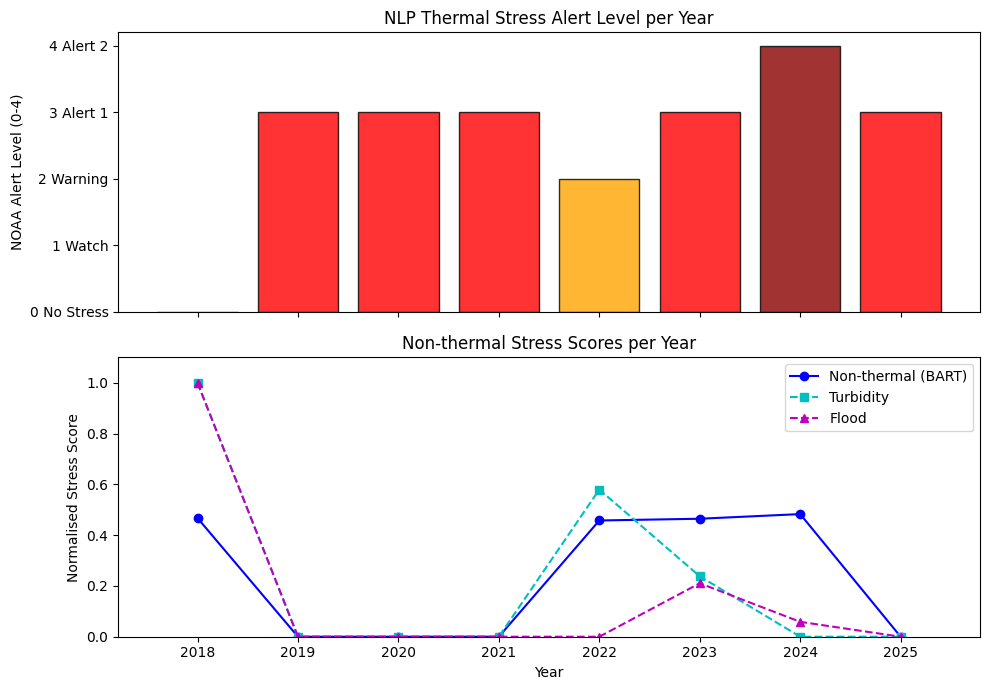

Saved → nlp_features_summary.png


In [17]:
#16
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

colors = ['green','yellow','orange','red','darkred']
bar_colors = [colors[min(lv, 4)] for lv in final_df['alert_level']]
axes[0].bar(final_df['year'], final_df['alert_level'], color=bar_colors, edgecolor='k', alpha=0.8)
axes[0].set_ylabel('NOAA Alert Level (0-4)')
axes[0].set_title('NLP Thermal Stress Alert Level per Year')
axes[0].set_yticks([0,1,2,3,4])
axes[0].set_yticklabels(['0 No Stress','1 Watch','2 Warning','3 Alert 1','4 Alert 2'])

axes[1].plot(final_df['year'], final_df['nlp_nonthermal_score'], 'b-o', label='Non-thermal (BART)')
axes[1].plot(final_df['year'], final_df['turbidity'], 'c--s', label='Turbidity')
axes[1].plot(final_df['year'], final_df['flood'], 'm--^', label='Flood')
axes[1].set_ylabel('Normalised Stress Score')
axes[1].set_xlabel('Year')
axes[1].set_title('Non-thermal Stress Scores per Year')
axes[1].legend()
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('nlp_features_summary.png', dpi=150)
plt.show()
print("Saved → nlp_features_summary.png")

In [18]:
#17
# How many AIMS sentences per year?
print(aims_df.groupby('year')['text'].count())

year
2019    226
2020    100
2021     69
2022      2
2023    140
2024    102
2025     80
Name: text, dtype: int64


In [19]:
print(aims_df['source'].unique())

['AIMS_LTMP_Report_GBR_coral_status_2024_2025_final_web.pdf'
 'AIMS_LTMP_Report_GBR_coral_status_2023_2024_final.pdf'
 'AIMS_LTMP_Report_on GBR_coral_status_2021_2022_040822F3.pdf'
 'AIMS_LTMP_AnnualSummaryReport_2019-20_Aug21_2020(2).pdf'
 'AIMS_LTMP_Report_GBR_coral_status_2022_2023_9August2023.pdf'
 'AIMS Long Term Monitoring Program Annual Summary Report on Coral Reef Condition (GBR) 2020-2021_July2021.pdf'
 'MMP WQ AIMS JCU report 2019_2020_FINAL.pdf' 'reef-health-updates.pdf'
 'past-reef-health-updates.pdf']
